
# 第二题：基于预测分位数的风险偏好策略扫描

本 Notebook 在原 `q2_strategy_compare.ipynb` 的调度约束与实际回放逻辑上，进一步把“保守 / 中庸 / 激进”从三个离散标签推广为连续的**风险分位数参数** $q$。

---

## 1. 正式数学定义

设第 $d$ 天、第 $t$ 个 10 分钟时段的净负荷预测场景为

$$
N_{d,t}^{(1)},N_{d,t}^{(2)},\ldots,N_{d,t}^{(S_d)}.
$$

对任意风险分位数 $q\in(0,1)$，定义用于日前决策的净负荷路径

$$
\widehat N_{d,t}^{(q)}
=
Q_q\left(
N_{d,t}^{(1)},\ldots,N_{d,t}^{(S_d)}
\right),
$$

其中 $Q_q$ 表示经验 $q$ 分位数。

对于给定 $q$，日前计划为

$$
\pi_d(q)
=
\arg\min_{\pi}
\sum_{t=1}^{144}p_t g_{d,t},
$$

并满足与原 Notebook 完全一致的储能约束、充放电效率、SOC 上下界、充放电功率限制以及日终储能约束。

计划确定后不允许根据真实净负荷重新调整电池。实际净负荷高于计划供给的缺口定义为紧急购电

$$
e_{d,t}(q)
=
\max\left\{
N^{\rm actual}_{d,t}
-
\big[g_{d,t}(q)+d_{d,t}(q)-c_{d,t}(q)\big],
0
\right\}.
$$

实际总费用定义为

$$
J(q)
=
\sum_{d,t}p_t g_{d,t}(q)
+
M\sum_{d,t}p_t e_{d,t}(q),
$$

其中本题紧急购电倍率

$$
M=5.
$$

最终风险分位数通过

$$
\boxed{
q^*=\arg\min_{q\in\mathcal Q}J(q)
}
$$

确定。

本实验取

$$
\mathcal Q=\{0.05,0.10,\ldots,0.95\}.
$$

---

### 1.1 理论参考：单时段临界分位数

若暂时忽略储能跨时段耦合，仅考虑“提前购电成本为 $p$，不足部分按 $Mp$ 紧急购电”的单时段问题，则其 newsvendor 临界分位数为

$$
q_0=1-\frac{1}{M}.
$$

由于本题 $M=5$，因此

$$
\boxed{q_0=0.8}.
$$

这只是理论参考。实际模型存在储能跨时段耦合、时变电价、充放电效率以及日终 SOC 约束，因此最终 $q^*$ 不要求等于 0.8。

---

### 1.2 与“30% / 50% / 70% 中央预测区间”的关系

中央覆盖率 $C$ 对应

$$
\left[
Q_{\frac{1-C}{2}},
Q_{\frac{1+C}{2}}
\right].
$$

因此：

| 中央预测区间 | 激进侧 | 保守侧 |
|---:|---:|---:|
| 30% | $p_{35}$ | $p_{65}$ |
| 50% | $p_{25}$ | $p_{75}$ |
| 70% | $p_{15}$ | $p_{85}$ |
| 90% | $p_{05}$ | $p_{95}$ |

本 Notebook 不只比较这几个离散点，而是完整扫描 $p05\sim p95$，再从结果中提取上述 30% / 50% / 70% / 90% 中央区间对应策略。



## 2. 导入库、路径和统一参数

说明：

1. 调度物理约束沿用原 `q2_strategy_compare.ipynb`；
2. 当前预测层暂时沿用已经完成调参与消融后的 **W=30** 模型，不在本 Notebook 中改成 W=60；
3. 任意分位数直接从预测场景取经验分位数，**不对 p05 / p50 / p95 做线性插值**；
4. 14 日滚动共形校准只校准 80% / 90% 区间边界，并不定义完整 CDF，因此本分位数扫描不把该区间扩张量硬套到所有 $q$ 上。


In [2]:

from pathlib import Path
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import Bounds, LinearConstraint, linprog, milp
from scipy.sparse import coo_matrix, csr_matrix, hstack
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

try:
    from IPython.display import display
except ModuleNotFoundError:
    display = print

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 180)

# ------------------------------------------------------------
# 项目根目录
# ------------------------------------------------------------
START_DIR = Path.cwd()
ROOT = START_DIR
while not (ROOT / "C题.md").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if not (ROOT / "C题.md").exists():
    ROOT = START_DIR

PREDICT_XLSX = ROOT / "q2" / "results" / "predict_with_price.xlsx"

ACTUAL_CANDIDATES = [
    ROOT / "q2" / "input" / "q2_actual_load_pv.csv",
    ROOT / "q2_actual_load_pv.csv",
    ROOT / "Data_preprocessed" / "processed" / "actuals_10min.csv",
]
ACTUAL_CSV = next((p for p in ACTUAL_CANDIDATES if p.exists()), None)

OUT_DIR = ROOT / "q2" / "results" / "strategy_quantile_sweep"
OUT_DIR.mkdir(parents=True, exist_ok=True)

CFG = {
    "interval_minutes": 10,
    "charge_efficiency": 0.9,
    "discharge_efficiency": 0.9,
    "storage_min_kwh": 1200.0,
    "storage_max_kwh": 10800.0,
    "initial_storage_kwh": 6000.0,
    "terminal_storage_kwh": 6000.0,
    "max_charge_power_kw": 5000.0,
    "max_discharge_power_kw": 5000.0,
    "emergency_multiplier": 5.0,
    "tolerance": 1e-6,
}

# W=30 最终中心预测结构：暂不统一到 W=60
FORECAST_CFG = {
    "window_days": 30,
    "k_load": 3,
    "k_pv": 2,
    "alpha_load": 3.0,
    "alpha_pv": 30.0,
    "scenario_days": 28,
    "start_day": 14,
}

Q_GRID = np.round(np.arange(0.05, 0.951, 0.05), 2)
THEORETICAL_Q = 1.0 - 1.0 / CFG["emergency_multiplier"]

print("项目根目录:", ROOT)
print("预测工作簿:", PREDICT_XLSX)
print("实际负荷/PV:", ACTUAL_CSV)
print("策略扫描 q:", Q_GRID)
print("单时段理论临界分位数 q0 =", THEORETICAL_Q)


项目根目录: e:\桌面\CUMCM_2026
预测工作簿: e:\桌面\CUMCM_2026\q2\results\predict_with_price.xlsx
实际负荷/PV: e:\桌面\CUMCM_2026\Data_preprocessed\processed\actuals_10min.csv
策略扫描 q: [0.05 0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.65 0.7
 0.75 0.8  0.85 0.9  0.95]
单时段理论临界分位数 q0 = 0.8



## 3. 读取电价与全年实际负荷 / 光伏

`predict_with_price.xlsx` 继续作为第二题调度侧的电价来源。  
全年负荷与光伏用于重新构造 W=30 最终预测模型的历史残差场景，从而得到 $p05,p10,\ldots,p95$ 的完整分位数路径。


In [3]:

def require(condition, message):
    if not bool(condition):
        raise ValueError(message)


def load_price_workbook(path: Path):
    if not path.exists():
        raise FileNotFoundError(
            f"未找到 {path}。请先生成 q2/results/predict_with_price.xlsx。"
        )
    xls = pd.ExcelFile(path)
    frames = []
    for sheet in xls.sheet_names:
        df = pd.read_excel(path, sheet_name=sheet)
        required = ["时间", "电价", "实际净负载"]
        missing = [c for c in required if c not in df.columns]
        if missing:
            raise KeyError(f"{sheet} 缺少列: {missing}")
        if len(df) != 144:
            raise ValueError(f"{sheet} 行数为 {len(df)}，期望 144")
        keep = required + [c for c in ["净负载p05", "净负载p50", "净负载p95"] if c in df.columns]
        part = df[keep].copy()
        part.insert(0, "date", pd.Timestamp(sheet))
        part.insert(1, "slot", np.arange(1, 145))
        frames.append(part)
    out = pd.concat(frames, ignore_index=True)
    return out


def load_actual_csv(path: Path):
    if path is None or not path.exists():
        raise FileNotFoundError(
            "未找到 q2_actual_load_pv.csv / actuals_10min.csv。"
        )
    df = pd.read_csv(path, encoding="utf-8-sig")
    date_col = "date" if "date" in df.columns else "source_date"
    require(date_col in df.columns, "实际数据缺少 date/source_date")
    require({"load_kw", "pv_kw"}.issubset(df.columns), "实际数据缺少 load_kw/pv_kw")
    df[date_col] = pd.to_datetime(df[date_col])
    if "slot" in df.columns:
        df = df.sort_values([date_col, "slot"]).reset_index(drop=True)
        require(df.duplicated([date_col, "slot"]).sum() == 0, "存在重复 date-slot")
    else:
        df = df.sort_values(date_col).reset_index(drop=True)
    counts = df.groupby(date_col).size()
    require(counts.min() == counts.max() == 144, "存在日期不是 144 个时段")
    require(np.isfinite(df[["load_kw", "pv_kw"]].to_numpy(float)).all(), "负荷/PV 存在非法数值")
    return df, date_col


price_raw = load_price_workbook(PREDICT_XLSX)
actual_df, actual_date_col = load_actual_csv(ACTUAL_CSV)

DATES = pd.DatetimeIndex(actual_df[actual_date_col].drop_duplicates())
LOAD = actual_df["load_kw"].to_numpy(float).reshape(-1, 144)
PV = actual_df["pv_kw"].to_numpy(float).reshape(-1, 144)

eval_dates = pd.DatetimeIndex(price_raw["date"].drop_duplicates())
require(eval_dates[0] >= DATES[0], "评价日期早于实际数据起点")
prices = price_raw[price_raw["date"].eq(eval_dates[0])]["电价"].to_numpy(float)
require(len(prices) == 144 and np.all(prices > 0), "电价数据异常")

date_to_idx = {d: i for i, d in enumerate(DATES)}
EVAL_IDX = np.array([date_to_idx[d] for d in eval_dates], dtype=int)

# 核对工作簿里的实际净负荷和实际数据是否一致
actual_net_kw = LOAD - PV
book_actual = price_raw["实际净负载"].to_numpy(float).reshape(len(eval_dates), 144)
max_actual_diff = float(np.max(np.abs(book_actual - actual_net_kw[EVAL_IDX])))

print(f"全年实际数据: {DATES[0].date()} ~ {DATES[-1].date()}, {len(DATES)} 天")
print(f"策略评价期: {eval_dates[0].date()} ~ {eval_dates[-1].date()}, {len(eval_dates)} 天")
print(f"工作簿实际净负荷 vs CSV 最大差异: {max_actual_diff:.6g} kW")
require(max_actual_diff <= 1e-3, "工作簿实际净负荷与实际数据不一致，请先统一数据版本。")


全年实际数据: 2025-01-01 ~ 2025-12-31, 365 天
策略评价期: 2025-02-01 ~ 2025-12-31, 334 天
工作簿实际净负荷 vs CSV 最大差异: 9.09495e-13 kW



## 4. 重新构造 W=30 最终预测场景

这里直接使用此前调参与消融后确定的 W=30 结构：

$$
K_L=3,\qquad K_P=2,
$$

$$
h_d^L=
[s^L_{d-1},s^L_{d-7}],
$$

$$
h_d^P=
[s^P_{d-1},s^P_{d-7},
\overline{s}^{P}_{d-7:d-1}],
$$

Load calendar 使用 “Fri/Sat / 其他日期” 两类编码，PV calendar 使用一阶年周期 Fourier 编码，

$$
\alpha_L=3,\qquad \alpha_P=30.
$$

预测完成后保留最近最多 28 天负荷与 PV 的**成对整日残差**，构造下一日场景：

$$
L^{(s)}_d=\max(\widehat L_d+e^{L,(s)},0),
$$

$$
P^{(s)}_d=\max(\widehat P_d+e^{P,(s)},0),
$$

$$
N^{(s)}_d=L^{(s)}_d-P^{(s)}_d.
$$

因此任意 $q$ 都是直接从场景集合取经验分位数，而不是从已有 p05/p50/p95 插值。


In [4]:

def pca_basis(curves, k):
    mu = curves.mean(axis=0)
    _, _, vt = np.linalg.svd(curves - mu, full_matrices=False)
    return mu, vt[:k]


def load_history_features(score_l, j):
    # H1: lag1 + lag7
    return np.r_[score_l[j-1], score_l[j-7]]


def pv_history_features(score_p, j):
    # H2: lag1 + lag7 + mean7
    return np.r_[score_p[j-1], score_p[j-7], score_p[j-7:j].mean(axis=0)]


def load_calendar(date):
    # 2 维 one-hot: 其他日期 / Fri-Sat
    is_fri_sat = int(date.weekday() in (4, 5))
    return np.eye(2)[is_fri_sat]


def pv_calendar(date):
    doy = date.dayofyear
    return np.array([
        np.sin(2*np.pi*doy/365.25),
        np.cos(2*np.pi*doy/365.25),
    ])


def run_w30_forecast_scenarios():
    cfg = FORECAST_CFG
    pred_l = np.full_like(LOAD, np.nan)
    pred_p = np.full_like(PV, np.nan)
    scenarios = {}
    residual_bank = []

    for d in range(cfg["start_day"], len(DATES)):
        h0 = max(0, d - cfg["window_days"])

        mu_l, phi_l = pca_basis(LOAD[h0:d], cfg["k_load"])
        mu_p, phi_p = pca_basis(PV[h0:d], cfg["k_pv"])

        score_l = (LOAD - mu_l) @ phi_l.T
        score_p = (PV - mu_p) @ phi_p.T

        train_days = np.arange(max(h0 + 7, 7), d)
        if len(train_days) == 0:
            continue

        def f_load(j):
            return np.r_[load_calendar(DATES[j]), load_history_features(score_l, j)]

        def f_pv(j):
            return np.r_[pv_calendar(DATES[j]), pv_history_features(score_p, j)]

        X_l = np.vstack([f_load(j) for j in train_days])
        X_p = np.vstack([f_pv(j) for j in train_days])

        model_l = make_pipeline(
            StandardScaler(),
            Ridge(alpha=cfg["alpha_load"]),
        ).fit(X_l, score_l[train_days])

        model_p = make_pipeline(
            StandardScaler(),
            Ridge(alpha=cfg["alpha_pv"]),
        ).fit(X_p, score_p[train_days])

        sl_hat = np.atleast_1d(model_l.predict(f_load(d)[None, :])[0])
        sp_hat = np.atleast_1d(model_p.predict(f_pv(d)[None, :])[0])

        pred_l[d] = np.maximum(mu_l + sl_hat @ phi_l, 0)
        pred_p[d] = np.maximum(mu_p + sp_hat @ phi_p, 0)

        if residual_bank:
            recent = residual_bank[-cfg["scenario_days"]:]
            err_l = np.array([x[0] for x in recent])
            err_p = np.array([x[1] for x in recent])

            load_s = np.maximum(pred_l[d][None, :] + err_l, 0)
            pv_s = np.maximum(pred_p[d][None, :] + err_p, 0)
            scenarios[d] = load_s - pv_s

        residual_bank.append((
            LOAD[d] - pred_l[d],
            PV[d] - pred_p[d],
        ))

    return pred_l, pred_p, scenarios


started = time.perf_counter()
PRED_LOAD, PRED_PV, SCENARIOS = run_w30_forecast_scenarios()
print(f"W=30 场景构造完成，用时 {time.perf_counter()-started:.1f}s")
print("评价期有场景天数:", sum(int(d in SCENARIOS) for d in EVAL_IDX), "/", len(EVAL_IDX))
require(all(d in SCENARIOS for d in EVAL_IDX), "评价期存在无场景日期，不能继续分位数扫描。")


W=30 场景构造完成，用时 1.7s
评价期有场景天数: 334 / 334



## 5. 生成 $p05\sim p95$ 的完整分位数路径

所有分位数均由同一组预测场景直接计算。  
同时若旧工作簿包含 p05 / p50 / p95，会额外给出一致性对比；该对比仅用于版本核查，不参与新策略定义。


In [5]:

quantile_paths_kw = {}

for q in Q_GRID:
    quantile_paths_kw[q] = np.vstack([
        np.quantile(SCENARIOS[d], q, axis=0)
        for d in EVAL_IDX
    ])

quantile_paths_kwh = {
    q: arr * CFG["interval_minutes"] / 60.0
    for q, arr in quantile_paths_kw.items()
}

# 可选：与旧工作簿已有 p05/p50/p95 做版本核对
legacy_checks = []
for q, col in [(0.05, "净负载p05"), (0.50, "净负载p50"), (0.95, "净负载p95")]:
    if col in price_raw.columns:
        old = price_raw[col].to_numpy(float).reshape(len(eval_dates), 144)
        new = quantile_paths_kw[q]
        legacy_checks.append({
            "q": q,
            "旧工作簿列": col,
            "MAE差异(kW)": float(np.mean(np.abs(old-new))),
            "RMSE差异(kW)": float(np.sqrt(np.mean((old-new)**2))),
        })

if legacy_checks:
    print("旧工作簿与当前 W=30 场景版本核对：")
    display(pd.DataFrame(legacy_checks).round(4))

# 导出分位数路径，供论文或其他程序复用
q_export = pd.DataFrame({
    "date": np.repeat(eval_dates.strftime("%Y-%m-%d"), 144),
    "slot": np.tile(np.arange(1,145), len(eval_dates)),
    "actual_net_kw": actual_net_kw[EVAL_IDX].reshape(-1),
    "price_yuan_per_kwh": np.tile(prices, len(eval_dates)),
})
for q in Q_GRID:
    q_export[f"net_p{int(round(q*100)):02d}_kw"] = quantile_paths_kw[q].reshape(-1)

q_export.to_csv(
    OUT_DIR / "netload_quantiles_p05_p95.csv",
    index=False,
    encoding="utf-8-sig",
)
display(q_export.head())


旧工作簿与当前 W=30 场景版本核对：


,q,旧工作簿列,MAE差异(kW),RMSE差异(kW)
0,0.05,净负载p05,182.3792,287.3468
1,0.50,净负载p50,157.8817,242.0213
2,0.95,净负载p95,171.7306,258.6406


,date,slot,actual_net_kw,price_yuan_per_kwh,net_p05_kw,net_p10_kw,net_p15_kw,net_p20_kw,net_p25_kw,net_p30_kw,net_p35_kw,net_p40_kw,net_p45_kw,net_p50_kw,net_p55_kw,net_p60_kw,net_p65_kw,net_p70_kw,net_p75_kw,net_p80_kw,net_p85_kw,net_p90_kw,net_p95_kw
0,2025-02-01,1,2532.1822,0.4248,2367.276021,2448.936382,2482.487463,2498.083206,2523.576201,2535.427621,2572.634275,2604.036610,2618.719103,2626.010257,2641.072526,2653.526661,2661.531507,2674.691779,2714.058065,2720.478251,2742.405737,2764.885607,2781.117369
1,2025-02-01,2,2492.4439,0.4245,2437.011335,2492.161577,2511.557874,2515.336638,2528.613622,2558.984632,2566.664629,2576.735810,2599.081825,2628.387769,2659.375249,2671.922832,2691.687231,2721.555327,2741.644162,2792.145393,2831.987605,2851.310873,2863.380629
2,2025-02-01,3,2464.3000,0.4269,2598.621682,2603.913120,2613.513671,2627.497057,2644.978786,2654.244530,2673.964860,2692.162778,2712.834901,2755.951459,2764.421287,2777.105890,2792.686571,2809.766667,2826.871556,2827.049986,2868.021625,2930.199922,2993.956341
3,2025-02-01,4,2581.7688,0.4272,2603.424912,2642.741116,2665.166635,2689.065488,2691.130507,2693.787490,2704.423847,2733.194648,2770.036623,2784.668163,2787.303205,2789.246486,2797.726036,2810.715834,2816.935803,2842.155348,2859.293399,2880.109880,2903.514511
4,2025-02-01,5,2546.4635,0.4271,2618.547149,2628.896903,2638.777435,2656.294331,2703.333387,2708.686246,2747.935339,2777.491551,2785.296082,2790.820443,2830.297420,2848.205666,2864.187695,2883.446202,2896.744067,2912.107957,2916.821926,2946.389833,2991.448860



## 6. 日前储能调度与真实执行

以下函数直接沿用原 `q2_strategy_compare.ipynb` 的物理口径：

- $g_t$：普通购电；
- $c_t,d_t$：充放电；
- $u_t$：未利用电量；
- $E_t$：储能；
- 充、放电效率均为 90%；
- SOC 范围 1200–10800 kWh；
- 最大充/放电功率 5000 kW；
- 每天计划末态为 6000 kWh；
- 实际执行时不根据真实净负荷临时修改储能轨迹；
- 不足部分按 5 倍电价紧急购电。


In [6]:

def solve_dispatch_for_net(net_kwh, prices, initial_kwh, terminal_kwh, cfg=CFG, solver="auto"):
    """给定一条净负载路径，求普通购电与储能调度的最小计划购电费。"""
    net = np.asarray(net_kwh, dtype=float)
    p = np.asarray(prices, dtype=float)
    n = len(net)

    require(n == len(p), "净负载和价格长度不一致")
    require(np.isfinite(net).all() and np.isfinite(p).all() and (p > 0).all(), "输入存在非法数值")

    eta_c = cfg["charge_efficiency"]
    eta_d = cfg["discharge_efficiency"]
    mc = cfg["max_charge_power_kw"] * cfg["interval_minutes"] / 60
    md = cfg["max_discharge_power_kw"] * cfg["interval_minutes"] / 60
    lo = cfg["storage_min_kwh"]
    hi = cfg["storage_max_kwh"]

    # x = [g(n), c(n), d(n), u(n), E(n+1)]
    count = 5*n + 1
    obj = np.zeros(count)
    obj[:n] = p

    rows, cols, data = [], [], []
    rhs = np.zeros(2*n)
    t = np.arange(n)

    # g + d - c - u = net
    rows.extend(t); cols.extend(t); data.extend(np.ones(n))
    rows.extend(t); cols.extend(2*n+t); data.extend(np.ones(n))
    rows.extend(t); cols.extend(n+t); data.extend(-np.ones(n))
    rows.extend(t); cols.extend(3*n+t); data.extend(-np.ones(n))
    rhs[:n] = net

    # E[t+1] - E[t] - eta_c*c + d/eta_d = 0
    r = n + t
    rows.extend(r); cols.extend(4*n+t+1); data.extend(np.ones(n))
    rows.extend(r); cols.extend(4*n+t); data.extend(-np.ones(n))
    rows.extend(r); cols.extend(n+t); data.extend(-eta_c*np.ones(n))
    rows.extend(r); cols.extend(2*n+t); data.extend(np.ones(n)/eta_d)

    eq = coo_matrix((data, (rows, cols)), shape=(2*n, count)).tocsr()

    lower = np.zeros(count)
    upper = np.full(count, np.inf)
    upper[n:2*n] = mc
    upper[2*n:3*n] = md
    lower[4*n:] = lo
    upper[4*n:] = hi
    lower[4*n] = upper[4*n] = initial_kwh
    lower[5*n] = upper[5*n] = terminal_kwh

    lp = linprog(
        obj,
        A_eq=eq,
        b_eq=rhs,
        bounds=np.column_stack([lower, upper]),
        method="highs",
    )
    if not lp.success:
        raise RuntimeError("LP failed: " + lp.message)

    x = lp.x
    used_solver = "HiGHS LP"

    # 如 LP 出现同时充放电，则切换 MILP 强制互斥
    overlap = (
        (x[n:2*n] > cfg["tolerance"])
        &
        (x[2*n:3*n] > cfg["tolerance"])
    )

    if solver == "milp" or overlap.any():
        mode_rows = np.r_[t, t, n+t, n+t]
        mode_cols = np.r_[n+t, count+t, 2*n+t, count+t]
        mode_data = np.r_[
            np.ones(n), -mc*np.ones(n),
            np.ones(n), md*np.ones(n),
        ]
        mode = coo_matrix(
            (mode_data, (mode_rows, mode_cols)),
            shape=(2*n, count+n),
        ).tocsr()

        res = milp(
            np.r_[obj, np.zeros(n)],
            integrality=np.r_[np.zeros(count), np.ones(n)],
            bounds=Bounds(
                np.r_[lower, np.zeros(n)],
                np.r_[upper, np.ones(n)],
            ),
            constraints=[
                LinearConstraint(
                    hstack([eq, csr_matrix((2*n, n))]),
                    rhs, rhs,
                ),
                LinearConstraint(
                    mode,
                    -np.inf,
                    np.r_[np.zeros(n), md*np.ones(n)],
                ),
            ],
            options={"mip_rel_gap": 1e-8},
        )
        if not res.success:
            raise RuntimeError("MILP failed: " + res.message)
        x = res.x[:count]
        used_solver = "HiGHS MILP"

    residual = float(np.max(np.abs(eq @ x - rhs)))
    require(residual <= 1e-5, f"调度等式残差过大: {residual}")

    return {
        "grid": np.maximum(x[:n], 0),
        "charge": np.maximum(x[n:2*n], 0),
        "discharge": np.maximum(x[2*n:3*n], 0),
        "unused": np.maximum(x[3*n:4*n], 0),
        "storage": x[4*n:],
        "cost": float(p @ np.maximum(x[:n], 0)),
        "solver": used_solver,
        "residual": residual,
    }


def execute_plan_on_actual(plan, actual_net_kwh, initial_kwh, cfg=CFG):
    """严格执行日前计划；真实缺口用紧急购电补齐。"""
    grid = np.asarray(plan["grid"], float)
    charge = np.asarray(plan["charge"], float)
    discharge = np.asarray(plan["discharge"], float)
    storage = np.asarray(plan["storage"], float)
    net = np.asarray(actual_net_kwh, float)

    require(len(grid) == len(net) == len(charge) == len(discharge), "计划和实际曲线长度不一致")
    require(abs(storage[0] - initial_kwh) <= 1e-6, "期初储能不一致")
    require(storage.min() >= cfg["storage_min_kwh"]-1e-6, "SOC 下界越界")
    require(storage.max() <= cfg["storage_max_kwh"]+1e-6, "SOC 上界越界")

    planned_supply_after_battery = grid + discharge - charge
    emergency = np.maximum(net - planned_supply_after_battery, 0.0)
    unused = np.maximum(planned_supply_after_battery - net, 0.0)

    balance = grid + discharge + emergency - net - charge - unused
    require(np.max(np.abs(balance)) <= 1e-6, "实际执行能量平衡失败")

    return {
        "emergency": emergency,
        "unused": unused,
        "storage": storage,
    }



## 7. 扫描风险分位数 $q$

对每个

$$
q=0.05,0.10,\ldots,0.95
$$

逐日执行：

1. 从预测场景取 $\widehat N_d^{(q)}$；
2. 用该路径制定当天完整储能与购电计划；
3. 固定该计划，在真实净负荷上回放；
4. 记录普通购电、紧急购电、未利用电量以及总费用。

因此不同 $q$ 之间的差异只来自**风险偏好位置不同**，储能物理参数和求解逻辑完全相同。


In [7]:

actual_eval_kwh = actual_net_kw[EVAL_IDX] * CFG["interval_minutes"] / 60.0

def run_quantile_strategy(q, forecast_net_kwh, progress=False):
    state = CFG["initial_storage_kwh"]
    day_rows = []
    started = time.perf_counter()

    for k, date in enumerate(eval_dates):
        plan = solve_dispatch_for_net(
            forecast_net_kwh[k],
            prices,
            initial_kwh=state,
            terminal_kwh=CFG["terminal_storage_kwh"],
            cfg=CFG,
        )

        actual = execute_plan_on_actual(
            plan,
            actual_eval_kwh[k],
            state,
            CFG,
        )

        planned_cost = float(prices @ plan["grid"])
        emergency_cost = float(
            CFG["emergency_multiplier"]
            * prices
            @ actual["emergency"]
        )

        day_rows.append({
            "q": q,
            "date": date,
            "计划购电量(kWh)": float(plan["grid"].sum()),
            "紧急购电量(kWh)": float(actual["emergency"].sum()),
            "未利用电量(kWh)": float(actual["unused"].sum()),
            "计划费用(元)": planned_cost,
            "紧急费用(元)": emergency_cost,
            "总费用(元)": planned_cost + emergency_cost,
            "发生紧急购电": int(actual["emergency"].sum() > 1e-6),
            "期初储能(kWh)": state,
            "期末储能(kWh)": float(actual["storage"][-1]),
            "求解器": plan["solver"],
        })

        state = float(actual["storage"][-1])

        if progress and (k+1) % 100 == 0:
            print(f"q={q:.2f}: {k+1}/{len(eval_dates)} 天")

    elapsed = time.perf_counter() - started
    return pd.DataFrame(day_rows), elapsed


all_daily = []
timings = []

for q in Q_GRID:
    daily_q, elapsed = run_quantile_strategy(
        q,
        quantile_paths_kwh[q],
        progress=False,
    )
    all_daily.append(daily_q)
    timings.append({"q": q, "用时(s)": elapsed})
    print(f"q={q:.2f} 完成，用时 {elapsed:.2f}s")

DAILY = pd.concat(all_daily, ignore_index=True)
display(pd.DataFrame(timings).round(3))


q=0.05 完成，用时 2.09s
q=0.10 完成，用时 2.02s
q=0.15 完成，用时 2.05s
q=0.20 完成，用时 2.08s
q=0.25 完成，用时 2.03s
q=0.30 完成，用时 1.97s
q=0.35 完成，用时 1.92s
q=0.40 完成，用时 1.86s
q=0.45 完成，用时 1.90s
q=0.50 完成，用时 1.88s
q=0.55 完成，用时 1.90s
q=0.60 完成，用时 1.85s
q=0.65 完成，用时 1.88s
q=0.70 完成，用时 1.89s
q=0.75 完成，用时 1.92s
q=0.80 完成，用时 1.90s
q=0.85 完成，用时 1.95s
q=0.90 完成，用时 1.98s
q=0.95 完成，用时 1.96s


,q,用时(s)
0,0.05,2.090
1,0.10,2.025
2,0.15,2.048
3,0.20,2.077
4,0.25,2.035
5,0.30,1.966
6,0.35,1.917
7,0.40,1.861
8,0.45,1.903
9,0.50,1.880



## 8. 汇总 $J(q)$ 并寻找最优风险分位数


In [8]:

SUMMARY = DAILY.groupby("q", as_index=False).agg(
    **{
        "计划购电量(kWh)": ("计划购电量(kWh)", "sum"),
        "紧急购电量(kWh)": ("紧急购电量(kWh)", "sum"),
        "未利用电量(kWh)": ("未利用电量(kWh)", "sum"),
        "计划费用(元)": ("计划费用(元)", "sum"),
        "紧急费用(元)": ("紧急费用(元)", "sum"),
        "总费用(元)": ("总费用(元)", "sum"),
        "发生紧急购电天数": ("发生紧急购电", "sum"),
        "平均期初储能(kWh)": ("期初储能(kWh)", "mean"),
        "最终期末储能(kWh)": ("期末储能(kWh)", "last"),
    }
)

best_idx = SUMMARY["总费用(元)"].idxmin()
BEST = SUMMARY.loc[best_idx]
q_star = float(BEST["q"])

SUMMARY["相对最优q多花(元)"] = SUMMARY["总费用(元)"] - float(BEST["总费用(元)"])
SUMMARY["相对最优q多花比例"] = SUMMARY["相对最优q多花(元)"] / float(BEST["总费用(元)"])

print(f"经验最优风险分位数 q* = {q_star:.2f}")
print(f"单时段理论参考 q0 = {THEORETICAL_Q:.2f}")
display(SUMMARY.round(4))

SUMMARY.to_csv(
    OUT_DIR / "quantile_strategy_summary.csv",
    index=False,
    encoding="utf-8-sig",
)
DAILY.to_csv(
    OUT_DIR / "quantile_strategy_daily.csv",
    index=False,
    encoding="utf-8-sig",
)


经验最优风险分位数 q* = 0.85
单时段理论参考 q0 = 0.80


,q,计划购电量(kWh),紧急购电量(kWh),未利用电量(kWh),计划费用(元),紧急费用(元),总费用(元),发生紧急购电天数,平均期初储能(kWh),最终期末储能(kWh),相对最优q多花(元),相对最优q多花比例
0,0.05,1.734695e+07,3.199277e+06,1.393994e+06,1.041336e+07,1.244860e+07,2.286197e+07,334,6000.0,6000.0,8.368578e+06,0.5774
1,0.10,1.786480e+07,2.664203e+06,1.363225e+06,1.075191e+07,1.036434e+07,2.111625e+07,334,6000.0,6000.0,6.622860e+06,0.4570
2,0.15,1.824428e+07,2.294576e+06,1.362998e+06,1.099606e+07,8.940769e+06,1.993682e+07,334,6000.0,6000.0,5.443437e+06,0.3756
3,0.20,1.856485e+07,2.000668e+06,1.381254e+06,1.119948e+07,7.803252e+06,1.900273e+07,334,6000.0,6000.0,4.509341e+06,0.3111
4,0.25,1.885540e+07,1.757707e+06,1.421792e+06,1.138285e+07,6.860381e+06,1.824323e+07,334,6000.0,6000.0,3.749844e+06,0.2587
5,0.30,1.912499e+07,1.550216e+06,1.476991e+06,1.155234e+07,6.051076e+06,1.760342e+07,334,6000.0,6000.0,3.110028e+06,0.2146
6,0.35,1.937476e+07,1.371568e+06,1.542261e+06,1.171058e+07,5.353920e+06,1.706450e+07,334,6000.0,6000.0,2.571113e+06,0.1774
7,0.40,1.961855e+07,1.210206e+06,1.618853e+06,1.186560e+07,4.721362e+06,1.658697e+07,334,6000.0,6000.0,2.093579e+06,0.1445
8,0.45,1.985548e+07,1.066765e+06,1.706380e+06,1.201515e+07,4.161537e+06,1.617668e+07,334,6000.0,6000.0,1.683297e+06,0.1161
9,0.50,2.009286e+07,9.359484e+05,1.807177e+06,1.216517e+07,3.653652e+06,1.581883e+07,334,6000.0,6000.0,1.325439e+06,0.0915



## 9. 30% / 50% / 70% / 90% 中央区间对应策略

注意：这里的“30% / 50% / 70% / 90%”是**中央预测区间覆盖率**，不是直接的 p30 / p50 / p70。


In [9]:

central_levels = {
    "30%中央区间": (0.35, 0.65),
    "50%中央区间": (0.25, 0.75),
    "70%中央区间": (0.15, 0.85),
    "90%中央区间": (0.05, 0.95),
}

rows = []
for label, (q_low, q_high) in central_levels.items():
    for side, q in [("激进侧", q_low), ("保守侧", q_high)]:
        r = SUMMARY.loc[np.isclose(SUMMARY["q"], q)].iloc[0]
        rows.append({
            "中央区间": label,
            "策略侧": side,
            "q": q,
            "总费用(元)": r["总费用(元)"],
            "计划费用(元)": r["计划费用(元)"],
            "紧急费用(元)": r["紧急费用(元)"],
            "紧急购电量(kWh)": r["紧急购电量(kWh)"],
            "未利用电量(kWh)": r["未利用电量(kWh)"],
            "发生紧急购电天数": int(r["发生紧急购电天数"]),
        })

CENTRAL_COMPARE = pd.DataFrame(rows)
display(CENTRAL_COMPARE.round(4))

CENTRAL_COMPARE.to_csv(
    OUT_DIR / "central_interval_strategy_compare.csv",
    index=False,
    encoding="utf-8-sig",
)


,中央区间,策略侧,q,总费用(元),计划费用(元),紧急费用(元),紧急购电量(kWh),未利用电量(kWh),发生紧急购电天数
0,30%中央区间,激进侧,0.35,1.706450e+07,1.171058e+07,5.353920e+06,1.371568e+06,1.542261e+06,334
1,30%中央区间,保守侧,0.65,1.497870e+07,1.264285e+07,2.335845e+06,5.971543e+05,2.195008e+06,334
2,50%中央区间,激进侧,0.25,1.824323e+07,1.138285e+07,6.860381e+06,1.757707e+06,1.421792e+06,334
3,50%中央区间,保守侧,0.75,1.463379e+07,1.301610e+07,1.617694e+06,4.126862e+05,2.568947e+06,333
4,70%中央区间,激进侧,0.15,1.993682e+07,1.099606e+07,8.940769e+06,2.294576e+06,1.362998e+06,334
5,70%中央区间,保守侧,0.85,1.449339e+07,1.349941e+07,9.939761e+05,2.525420e+05,3.121486e+06,331
6,90%中央区间,激进侧,0.05,2.286197e+07,1.041336e+07,1.244860e+07,3.199277e+06,1.393994e+06,334
7,90%中央区间,保守侧,0.95,1.476484e+07,1.433243e+07,4.324041e+05,1.094253e+05,4.183030e+06,313



## 10. 论文图：总费用—风险分位数


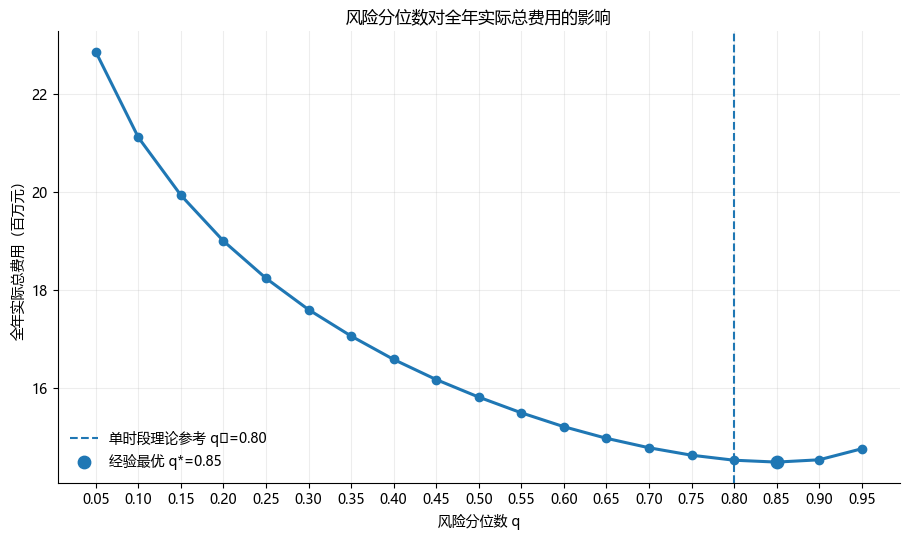

In [10]:

def set_chinese_font():
    import matplotlib.font_manager as fm
    candidates = [
        "Microsoft YaHei", "SimHei",
        "Noto Sans CJK SC", "Source Han Sans SC",
        "Arial Unicode MS",
    ]
    names = {f.name for f in fm.fontManager.ttflist}
    for name in candidates:
        if name in names:
            plt.rcParams["font.sans-serif"] = [name]
            break
    plt.rcParams["axes.unicode_minus"] = False

set_chinese_font()

fig, ax = plt.subplots(figsize=(9.2, 5.5))
ax.plot(
    SUMMARY["q"],
    SUMMARY["总费用(元)"] / 1e6,
    marker="o",
    linewidth=2.2,
)
ax.axvline(
    THEORETICAL_Q,
    linestyle="--",
    linewidth=1.5,
    label=f"单时段理论参考 q₀={THEORETICAL_Q:.2f}",
)
ax.scatter(
    [q_star],
    [BEST["总费用(元)"]/1e6],
    s=80,
    zorder=5,
    label=f"经验最优 q*={q_star:.2f}",
)
ax.set(
    xlabel="风险分位数 q",
    ylabel="全年实际总费用（百万元）",
    title="风险分位数对全年实际总费用的影响",
)
ax.set_xticks(Q_GRID)
ax.grid(alpha=.22)
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(OUT_DIR / "01_总费用_风险分位数.png", dpi=300, bbox_inches="tight")
plt.show()



## 11. 论文图：计划费用与紧急费用的权衡


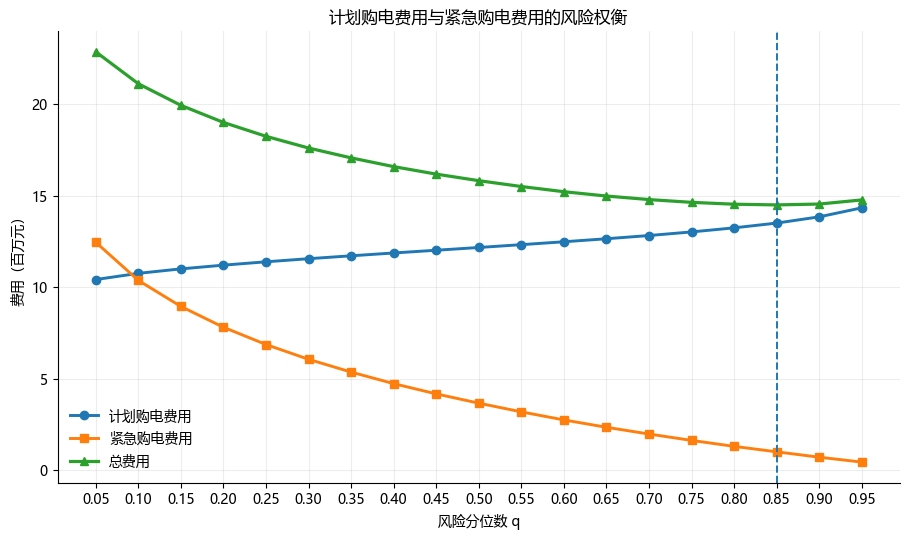

In [11]:

fig, ax = plt.subplots(figsize=(9.2, 5.5))
ax.plot(
    SUMMARY["q"],
    SUMMARY["计划费用(元)"] / 1e6,
    marker="o",
    linewidth=2.1,
    label="计划购电费用",
)
ax.plot(
    SUMMARY["q"],
    SUMMARY["紧急费用(元)"] / 1e6,
    marker="s",
    linewidth=2.1,
    label="紧急购电费用",
)
ax.plot(
    SUMMARY["q"],
    SUMMARY["总费用(元)"] / 1e6,
    marker="^",
    linewidth=2.3,
    label="总费用",
)
ax.axvline(q_star, linestyle="--", linewidth=1.4)
ax.set(
    xlabel="风险分位数 q",
    ylabel="费用（百万元）",
    title="计划购电费用与紧急购电费用的风险权衡",
)
ax.set_xticks(Q_GRID)
ax.grid(alpha=.22)
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(OUT_DIR / "02_费用构成_风险分位数.png", dpi=300, bbox_inches="tight")
plt.show()



## 12. 论文图：紧急购电与未利用电量


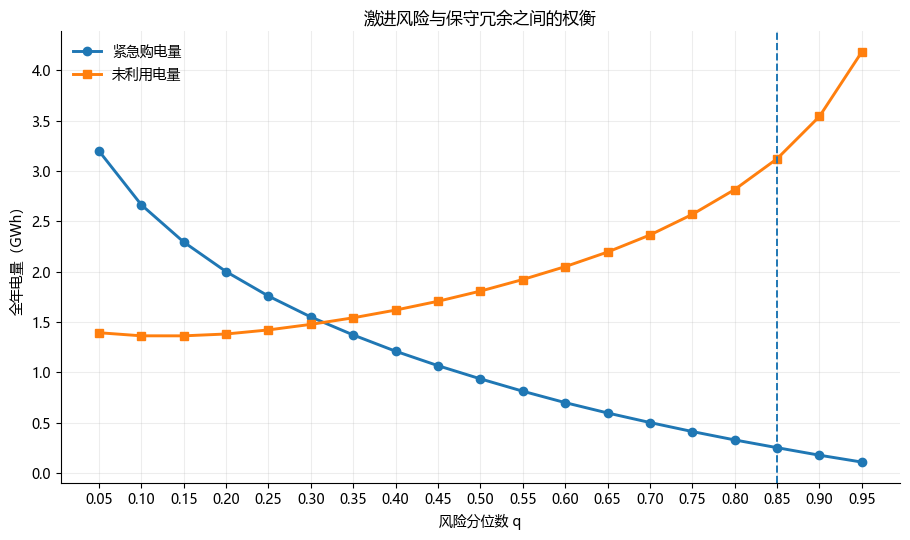

In [12]:

fig, ax = plt.subplots(figsize=(9.2, 5.5))
ax.plot(
    SUMMARY["q"],
    SUMMARY["紧急购电量(kWh)"] / 1e6,
    marker="o",
    linewidth=2.1,
    label="紧急购电量",
)
ax.plot(
    SUMMARY["q"],
    SUMMARY["未利用电量(kWh)"] / 1e6,
    marker="s",
    linewidth=2.1,
    label="未利用电量",
)
ax.axvline(q_star, linestyle="--", linewidth=1.4)
ax.set(
    xlabel="风险分位数 q",
    ylabel="全年电量（GWh）",
    title="激进风险与保守冗余之间的权衡",
)
ax.set_xticks(Q_GRID)
ax.grid(alpha=.22)
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(OUT_DIR / "03_紧急购电与未利用电量.png", dpi=300, bbox_inches="tight")
plt.show()



## 13. 论文图：紧急购电发生天数


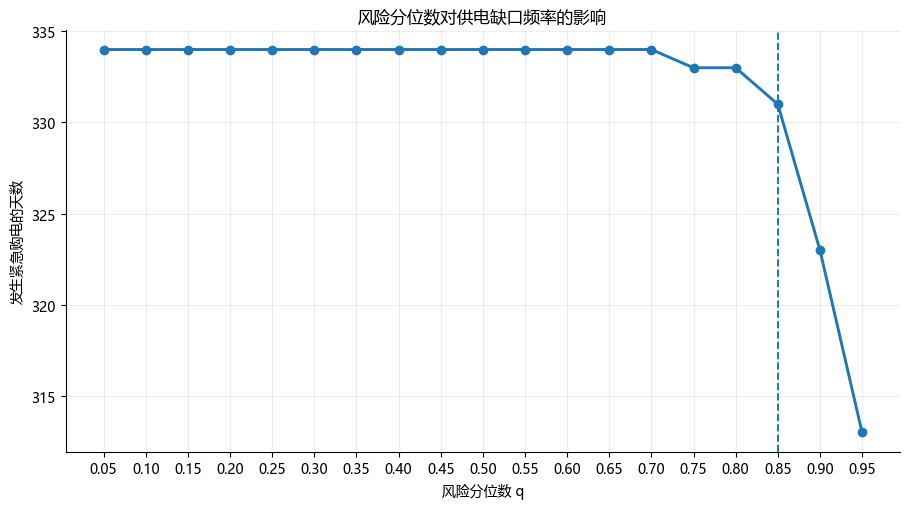

In [13]:

fig, ax = plt.subplots(figsize=(9.2, 5.2))
ax.plot(
    SUMMARY["q"],
    SUMMARY["发生紧急购电天数"],
    marker="o",
    linewidth=2.1,
)
ax.axvline(q_star, linestyle="--", linewidth=1.4)
ax.set(
    xlabel="风险分位数 q",
    ylabel="发生紧急购电的天数",
    title="风险分位数对供电缺口频率的影响",
)
ax.set_xticks(Q_GRID)
ax.grid(alpha=.22)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(OUT_DIR / "04_紧急购电发生天数.png", dpi=300, bbox_inches="tight")
plt.show()



## 14. 结果解释原则

最终论文不应再把 p05 / p50 / p95 简单描述成三个主观标签，而应按以下逻辑解释：

1. $q$ 是**风险偏好参数**；
2. $q$ 较小时，日前计划偏乐观，计划购电费用较低，但紧急购电风险较大；
3. $q$ 较大时，日前计划偏保守，紧急购电减少，但可能出现更多未利用电量以及更高的计划费用；
4. 实际总费用 $J(q)$ 同时受到两类成本影响，因此存在经济意义上的折中；
5. 经验最优 $q^*$ 由完整回测确定；
6. $q_0=0.8$ 是“无跨时段耦合”的理论临界分位数，只作为解释基准；
7. 如果 $q^*\neq0.8$，应从储能跨时段耦合、时变电价、效率损耗和日终 SOC 约束解释，而不是把它视为模型错误。


In [14]:

print("=" * 72)
print("分位数风险策略扫描完成")
print(f"经验最优 q* = {q_star:.2f}")
print(f"单时段理论参考 q0 = {THEORETICAL_Q:.2f}")
print(f"最优 q 全年实际总费用 = {BEST['总费用(元)']:,.2f} 元")
print(f"最优 q 紧急购电量 = {BEST['紧急购电量(kWh)']:,.2f} kWh")
print(f"最优 q 未利用电量 = {BEST['未利用电量(kWh)']:,.2f} kWh")
print(f"最优 q 发生紧急购电天数 = {int(BEST['发生紧急购电天数'])}")
print("输出目录:", OUT_DIR)
print("=" * 72)


分位数风险策略扫描完成
经验最优 q* = 0.85
单时段理论参考 q0 = 0.80
最优 q 全年实际总费用 = 14,493,387.01 元
最优 q 紧急购电量 = 252,541.98 kWh
最优 q 未利用电量 = 3,121,486.48 kWh
最优 q 发生紧急购电天数 = 331
输出目录: e:\桌面\CUMCM_2026\q2\results\strategy_quantile_sweep
